In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os
from langchain_groq import ChatGroq
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint

In [2]:

pip install langchain-groq

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
load_dotenv()

True

In [4]:
model = ChatGroq(
    model_name="qwen/qwen3.8-27b"
)


In [ ]:
# model= ChatHuggingFace(llm=llm)

In [33]:
print(model.invoke('hi how are you'))

content="Hi! I'm doing well, thanks for asking. How are you?" additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 16, 'total_tokens': 32, 'completion_time': 0.030522023, 'completion_tokens_details': None, 'prompt_time': 0.00080271, 'prompt_tokens_details': None, 'queue_time': 0.0432975, 'total_time': 0.031324733}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_21e59ac2de', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--01a1216b-193a-74d3-adb6-cf57895e853b-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 16, 'output_tokens': 16, 'total_tokens': 32}


In [34]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [39]:

class QnAState(TypedDict):
      qus:str
      ans:str

In [40]:
def Generate(state: QnAState)-> QnAState:

    qus=state['qus']
    ans=" "

    ans= model.invoke(qus).content
    
    state['ans']=ans

    return state
    


In [41]:
graph= StateGraph(QnAState)

graph.add_node('Generate', Generate)

graph.add_edge(START, 'Generate')
graph.add_edge('Generate', END)


workflow= graph.compile()



In [44]:
initial_state={'qus':'what is the capital of India and give me the best 10 places to visit there', 'ans':''}

final_state= workflow.invoke(initial_state)

print(final_state)

{'qus': 'what is the capital of India and give me the best 10 places to visit there', 'ans': 'The capital of India is **New Delhi**.\n\nHere are 10 of the best places to visit in and around New Delhi, combining historical landmarks, cultural sites, and iconic experiences:\n\n### 1. **India Gate**\n   - A war memorial containing the names of Indian and British soldiers who died in the World War I. It’s one of the most recognizable symbols of Delhi and a great spot for evening walks and people-watching.\n\n### 2. **Red Fort (Lal Qila)**\n   - A UNESCO World Heritage Site, this massive red sandstone fort was the main residence of the Mughal emperors. It’s where the Prime Minister hoists the Indian flag on Independence Day.\n\n### 3. **Qutub Minar**\n   - A 73-meter-tall victory tower built in the 12th century, it’s the tallest brick minaret in the world. The complex also includes the Iron Pillar and other historical tombs.\n\n### 4. **Humayun’s Tomb**\n   - A UNESCO World Heritage Site an

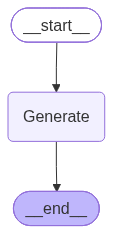

In [45]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())